## 1. IMPORT

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.lines as mlines
import random
import sys
import logging

sys.path.append('../src')

from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

from data_utils import prepare_source, inverse_close, N_FEATURES, CLOSE_IDX, TARGET_COLS
from model_utils import build_lstm_mimo, DEFAULT_EPOCHS, DEFAULT_PATIENCE
from evaluation import print_evaluation_report, summary_table

logging.getLogger('tensorflow').setLevel(logging.ERROR)
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

# Global style - konsisten dengan notebook LSTM+HHO
_C = dict(
    train   = '#A0AEC0',
    val_act = '#63B3ED',
    act     = '#378ADD',
    val_p   = '#EF9F27',
    test_p  = '#E24B4A',
    split   = '#1D9E75',
    loss_tr = '#378ADD',
    loss_va = '#EF9F27',
)
HORIZON_COLORS = ['#1D9E75', '#63B3ED', '#EF9F27', '#E24B4A', '#7F77DD']

plt.rcParams.update({
    'figure.facecolor' : '#FFFFFF',
    'axes.facecolor'   : '#FFFFFF',
    'axes.edgecolor'   : '#E2E8F0',
    'axes.linewidth'   : 0.8,
    'axes.grid'        : True,
    'grid.color'       : '#E2E8F0',
    'grid.linewidth'   : 0.6,
    'grid.alpha'       : 1.0,
    'xtick.color'      : '#888888',
    'ytick.color'      : '#888888',
    'xtick.labelsize'  : 9,
    'ytick.labelsize'  : 9,
    'font.family'      : 'sans-serif',
    'font.size'        : 10,
    'text.color'       : '#1A202C',
})

def _spine(ax):
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

def _fmt_usd(ax):
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))

def _fmt_date(ax):
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.get_xticklabels(), rotation=0, ha='center')

def _subtitle(ax, txt):
    ax.annotate(txt, xy=(0, 1.04), xycoords='axes fraction',
                fontsize=8.5, color='#718096')


## 2. LOAD & PREPROCESS

In [2]:
ds = prepare_source('nasdaq', n_input=60, n_forecast=5, data_dir='../data')
data = ds['data']

print(f"Data shape : {data.shape}")
print(f"Periode    : {data.index[0].date()} -> {data.index[-1].date()}")


Data shape : (1336, 5)
Periode    : 2021-01-04 -> 2026-04-29


## 3. WALK-FORWARD SPLIT (70 / 15 / 15)

> Split dilakukan **sebelum** scaling, mengikuti split time-ordered yang sama
> dengan notebook LSTM MIMO + HHO, agar perbandingan kedua model adil (BAB 3.6.2).

In [3]:
train_df, val_df, test_df = ds['train_df'], ds['val_df'], ds['test_df']

print("=" * 65)
print("  WALK-FORWARD SPLIT (70/15/15) - LSTM MIMO Standar (Baseline)")
print("=" * 65)
for label, d in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"  {label:<6} | {d.index[0].date()} -> {d.index[-1].date()} "
          f"| {len(d):>4} baris | Close min={d['Close'].min():.2f}  max={d['Close'].max():.2f}")


  WALK-FORWARD SPLIT (70/15/15) - LSTM MIMO Standar (Baseline)
  Train  | 2021-01-04 -> 2024-09-23 |  936 baris | Close min=11.23  max=135.58
  Val    | 2024-09-24 -> 2025-07-14 |  200 baris | Close min=94.31  max=164.92
  Test   | 2025-07-15 -> 2026-04-29 |  200 baris | Close min=165.17  max=216.61


## 4. NORMALISASI (Min-Max per Fitur, fit hanya pada Train)

Sesuai BAB 3.4.2: seluruh variabel input (Open, High, Low, Close, Volume) dinormalisasi
langsung menggunakan Min-Max Normalization ke rentang [0, 1]. Scaler di-fit **hanya**
pada data training untuk menghindari data leakage, lalu digunakan untuk transform
val/test.

In [4]:
scaler = ds['scaler']
train_scaled, val_scaled, test_scaled = ds['train_scaled'], ds['val_scaled'], ds['test_scaled']

print("Close price - scaler range (fit pada train):")
print(f"  min : {scaler.data_min_[CLOSE_IDX]:.4f}")
print(f"  max : {scaler.data_max_[CLOSE_IDX]:.4f}")


Close price - scaler range (fit pada train):
  min : 11.2270
  max : 135.5800


## 5. PEMBUATAN DATASET MIMO

In [5]:
n_input, n_forecast = ds['n_input'], ds['n_forecast']
X_train, y_train = ds['X_train'], ds['y_train']
X_val,   y_val   = ds['X_val'],   ds['y_val']
X_test,  y_test  = ds['X_test'],  ds['y_test']

print(f"X_train : {X_train.shape}  -> (samples, n_input={n_input}, N_FEATURES={N_FEATURES})")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}  -> (samples, n_forecast={n_forecast}) [skala 0-1]")


X_train : (871, 60, 5)  -> (samples, n_input=60, N_FEATURES=5)
X_val   : (135, 60, 5)
X_test  : (135, 60, 5)
y_train : (871, 5)  -> (samples, n_forecast=5) [skala 0-1]


## 6. GROUND TRUTH HARGA ABSOLUT (Inverse Transform Target)

In [6]:
y_train_abs = ds['y_train_abs']
y_val_abs   = ds['y_val_abs']
y_test_abs  = ds['y_test_abs']

print(f"y_train_abs : {y_train_abs.shape}  -> harga aktual dalam USD")
print(f"y_val_abs   : {y_val_abs.shape}")
print(f"y_test_abs  : {y_test_abs.shape}")
print(f"\nSample y_test_abs terakhir : {y_test_abs[-1].round(2)}")


y_train_abs : (871, 5)  -> harga aktual dalam USD
y_val_abs   : (135, 5)
y_test_abs  : (135, 5)

Sample y_test_abs terakhir : [202.5  199.64 208.27 216.61 213.17]


## 7. ARSITEKTUR MODEL LSTM MIMO STANDAR (Baseline)

Hyperparameter default sesuai BAB 3.5.1 (Tabel Arsitektur Model LSTM) — **tidak**
dioptimasi (ini adalah model baseline, dibandingkan dengan LSTM+HHO pada notebook lain).

| Hyperparameter        | Nilai Default |
|---|---|
| LSTM Layer 1 units    | 128 |
| LSTM Layer 2 units    | 64  |
| Dropout Rate          | 0.2 |
| Optimizer             | Adam |
| Learning rate         | 0.001 |
| Batch Size            | 32 |

In [7]:
UNITS_1        = 128
UNITS_2        = 64
DROPOUT_RATE   = 0.2
LEARNING_RATE  = 0.001
BATCH_SIZE     = 32
EPOCHS         = DEFAULT_EPOCHS
PATIENCE       = DEFAULT_PATIENCE

model = build_lstm_mimo(n_input, N_FEATURES, n_forecast,
                         UNITS_1, UNITS_2, DROPOUT_RATE, DROPOUT_RATE, LEARNING_RATE)
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 60, 128)           68608     
                                                                 
 dropout (Dropout)           (None, 60, 128)           0         
                                                                 
 lstm_1 (LSTM)               (None, 64)                49408     
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense (Dense)               (None, 5)                 325       
                                                                 
Total params: 118,341
Trainable params: 118,341
Non-trainable params: 0
_________________________________________________________________


## 8. TRAINING MODEL

In [8]:
early_stop = EarlyStopping(monitor='val_loss', patience=PATIENCE,
                           restore_best_weights=True, verbose=0)

print("\nTraining LSTM MIMO Standar (baseline, hyperparameter default)...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    shuffle=False, callbacks=[early_stop], verbose=1
)
print(f"\nTraining selesai pada epoch ke-{len(history.history['loss'])}")


Training LSTM MIMO Standar (baseline, hyperparameter default)...
Epoch 1/100
28/28 [==============================] - 6s 103ms/step - loss: 0.0193 - val_loss: 0.0496
Epoch 2/100
28/28 [==============================] - 2s 70ms/step - loss: 0.0274 - val_loss: 0.0124
Epoch 3/100
28/28 [==============================] - 2s 63ms/step - loss: 0.0159 - val_loss: 0.0105
Epoch 4/100
28/28 [==============================] - 2s 65ms/step - loss: 0.0169 - val_loss: 0.0148
Epoch 5/100
28/28 [==============================] - 2s 67ms/step - loss: 0.0093 - val_loss: 0.0116
Epoch 6/100
28/28 [==============================] - 2s 71ms/step - loss: 0.0093 - val_loss: 0.0128
Epoch 7/100
28/28 [==============================] - 2s 67ms/step - loss: 0.0085 - val_loss: 0.0118
Epoch 8/100
28/28 [==============================] - 2s 66ms/step - loss: 0.0081 - val_loss: 0.0138
Epoch 9/100
28/28 [==============================] - 2s 67ms/step - loss: 0.0062 - val_loss: 0.0156
Epoch 10/100
28/28 [=============

## 9. PREDIKSI & INVERSE TRANSFORM

In [9]:
train_pred_scaled = model.predict(X_train)
val_pred_scaled   = model.predict(X_val)
test_pred_scaled  = model.predict(X_test)

train_predict = inverse_close(scaler, train_pred_scaled)
val_predict   = inverse_close(scaler, val_pred_scaled)
test_predict  = inverse_close(scaler, test_pred_scaled)

print(f"train_predict : {train_predict.shape}  (dalam USD)")
print(f"val_predict   : {val_predict.shape}")
print(f"test_predict  : {test_predict.shape}")
print(f"\nSample test_predict terakhir : {test_predict[-1].round(2)}")
print(f"Ground truth terakhir        : {y_test_abs[-1].round(2)}")


5/5 [==============================] - 0s 18ms/step
train_predict : (871, 5)  (dalam USD)
val_predict   : (135, 5)
test_predict  : (135, 5)

Sample test_predict terakhir : [169.68 168.36 166.11 166.03 168.53]
Ground truth terakhir        : [202.5  199.64 208.27 216.61 213.17]


## 10. EVALUASI (RMSE, MAE, MAPE, DA per Horizon)


In [10]:
splits = {
    'TRAIN': (y_train_abs, train_predict, ds['anchor_train']),
    'VAL':   (y_val_abs,   val_predict,   ds['anchor_val']),
    'TEST':  (y_test_abs,  test_predict,  ds['anchor_test']),
}

print_evaluation_report("LSTM MIMO Standar (Baseline) - Nasdaq", n_forecast, splits)

val_dates  = ds['val_dates']
test_dates = ds['test_dates']



  EVALUASI TRAIN SET - LSTM MIMO Standar (Baseline)
  Horizon t+1 (Hari ke-1) | RMSE=  3.3765  MAE=  2.5897  MAPE=9.14%
  Horizon t+2 (Hari ke-2) | RMSE=  4.0459  MAE=  3.0416  MAPE=10.37%
  Horizon t+3 (Hari ke-3) | RMSE=  4.2098  MAE=  3.1688  MAPE=10.75%
  Horizon t+4 (Hari ke-4) | RMSE=  4.2767  MAE=  3.1369  MAPE=9.99%
  Horizon t+5 (Hari ke-5) | RMSE=  4.5682  MAE=  3.2829  MAPE=10.10%

  Average (all horizons)   | RMSE=  4.1146  MAE=  3.0440  MAPE=10.07%

  EVALUASI VAL SET - LSTM MIMO Standar (Baseline)
  Horizon t+1 (Hari ke-1) | RMSE=  7.3645  MAE=  5.9926  MAPE=4.77%
  Horizon t+2 (Hari ke-2) | RMSE=  8.5323  MAE=  6.8878  MAPE=5.56%
  Horizon t+3 (Hari ke-3) | RMSE=  9.3423  MAE=  7.7166  MAPE=6.12%
  Horizon t+4 (Hari ke-4) | RMSE= 10.1694  MAE=  8.6263  MAPE=6.76%
  Horizon t+5 (Hari ke-5) | RMSE= 10.5731  MAE=  8.7749  MAPE=6.92%

  Average (all horizons)   | RMSE=  9.2685  MAE=  7.5996  MAPE=6.03%

  EVALUASI TEST SET - LSTM MIMO Standar (Baseline)
  Horizon t+1 (Hari 

## 11. TABEL RINGKASAN EVALUASI (RMSE, MAE, MAPE, DA)


In [11]:
summary_table("LSTM MIMO Standar (Baseline) - Nasdaq", n_forecast, splits)



  RINGKASAN EVALUASI - LSTM MIMO STANDAR (BASELINE)
  Set      Horizon              RMSE        MAE       MAPE
  ------------------------------------------------------
  TRAIN    t+1 (Hari ke-1)     3.3765     2.5897      9.14%
  TRAIN    t+2 (Hari ke-2)     4.0459     3.0416     10.37%
  TRAIN    t+3 (Hari ke-3)     4.2098     3.1688     10.75%
  TRAIN    t+4 (Hari ke-4)     4.2767     3.1369      9.99%
  TRAIN    t+5 (Hari ke-5)     4.5682     3.2829     10.10%
  TRAIN    Average            4.1146     3.0440     10.07%
  ------------------------------------------------------
  VAL      t+1 (Hari ke-1)     7.3645     5.9926      4.77%
  VAL      t+2 (Hari ke-2)     8.5323     6.8878      5.56%
  VAL      t+3 (Hari ke-3)     9.3423     7.7166      6.12%
  VAL      t+4 (Hari ke-4)    10.1694     8.6263      6.76%
  VAL      t+5 (Hari ke-5)    10.5731     8.7749      6.92%
  VAL      Average            9.2685     7.5996      6.03%
  ------------------------------------------------------

## 12. PLOT - Training & Validation Loss

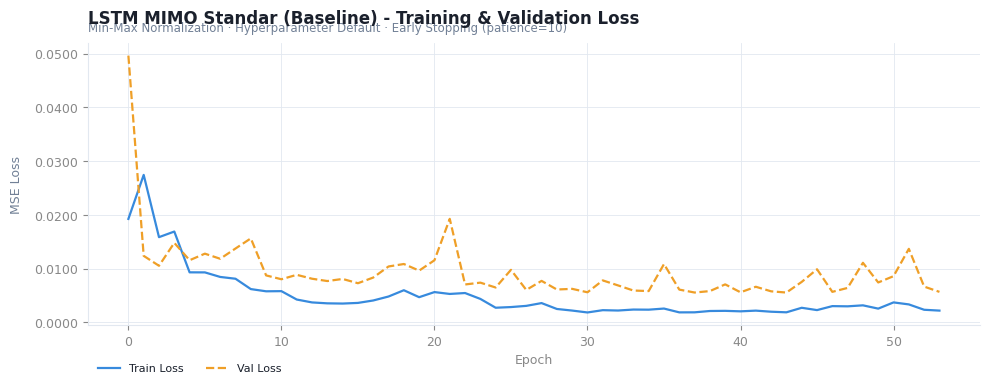

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
fig.subplots_adjust(top=0.86, bottom=0.12, left=0.09, right=0.97)

ax.plot(history.history['loss'],     color=_C['loss_tr'], lw=1.6, label='Train Loss')
ax.plot(history.history['val_loss'], color=_C['loss_va'], lw=1.6, label='Val Loss', ls='--')

_spine(ax)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.4f}'))
ax.set_ylabel('MSE Loss', fontsize=9, color='#718096', labelpad=8)
ax.set_xlabel('Epoch', fontsize=9, color='#888888')
ax.set_title('LSTM MIMO Standar (Baseline) - Training & Validation Loss',
             fontsize=12, fontweight='bold', color='#1A202C', loc='left', pad=14)
_subtitle(ax, f'Min-Max Normalization · Hyperparameter Default · Early Stopping (patience={PATIENCE})')

handles = [
    mlines.Line2D([], [], color=_C['loss_tr'], lw=1.6,          label='Train Loss'),
    mlines.Line2D([], [], color=_C['loss_va'], lw=1.6, ls='--', label='Val Loss'),
]
ax.legend(handles=handles, fontsize=8, frameon=False, ncol=2,
          loc='upper left', bbox_to_anchor=(0, -0.10))
plt.tight_layout(); plt.show()

## 13. PLOT - Aktual vs Prediksi (t+1)

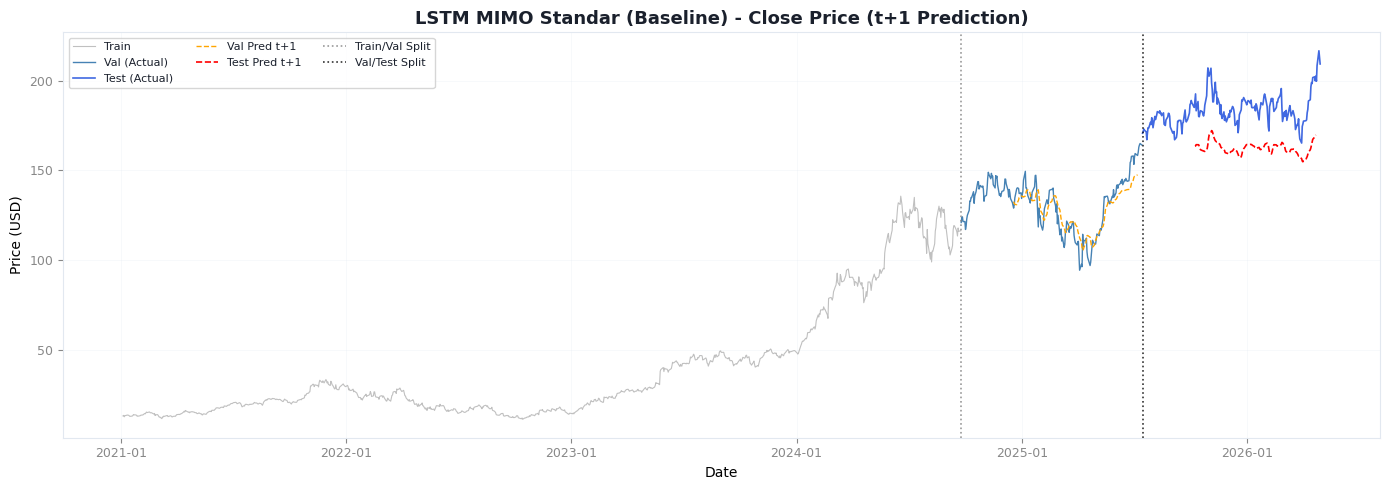

In [13]:
train_close_plot = train_df['Close']
val_close_plot   = val_df['Close']
test_close_plot  = test_df['Close']

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train_close_plot.index, train_close_plot,
        label='Train', color='silver', lw=0.8)
ax.plot(val_close_plot.index, val_close_plot,
        label='Val (Actual)', color='steelblue', lw=1.0)
ax.plot(test_close_plot.index, test_close_plot,
        label='Test (Actual)', color='royalblue', lw=1.2)
ax.plot(val_dates,  val_predict[:, 0],
        label='Val Pred t+1',  ls='--', color='orange', lw=1.0)
ax.plot(test_dates, test_predict[:, 0],
        label='Test Pred t+1', ls='--', color='red',    lw=1.2)
ax.axvline(val_df.index[0],  color='gray',  lw=1.2, ls=':', alpha=0.8, label='Train/Val Split')
ax.axvline(test_df.index[0], color='black', lw=1.2, ls=':', alpha=0.8, label='Val/Test Split')
ax.set_title('LSTM MIMO Standar (Baseline) - Close Price (t+1 Prediction)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Price (USD)'); ax.legend(fontsize=8, ncol=3)
ax.grid(alpha=0.3); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xlabel('Date'); plt.tight_layout(); plt.show()

## 14. PLOT - MIMO Forecast (Semua Horizon)

1/1 [==============================] - 0s 24ms/step


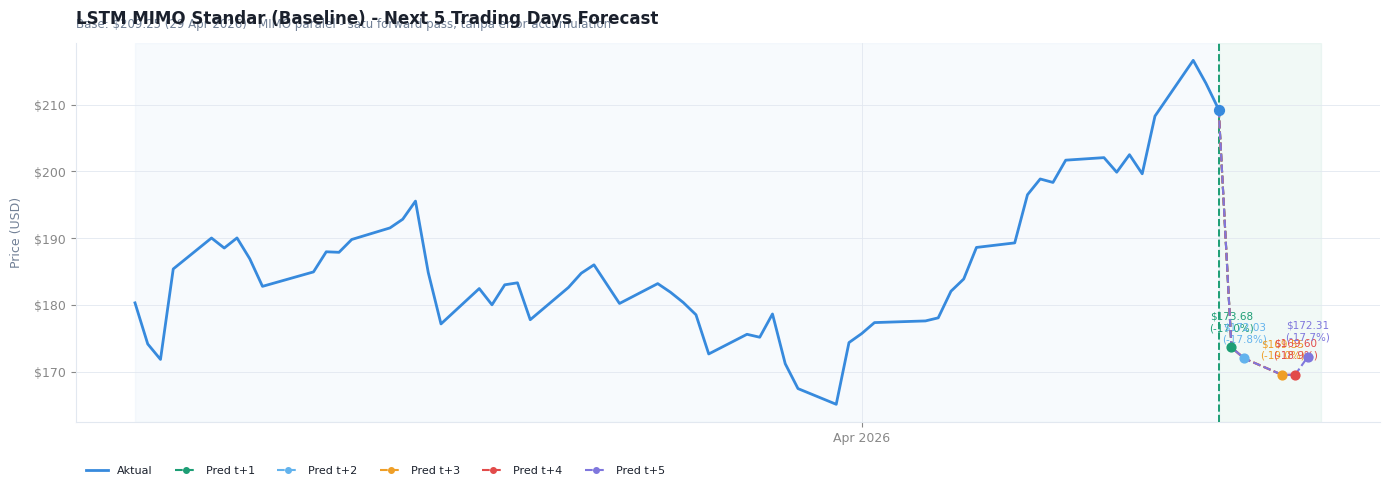

In [14]:
last_seq      = test_scaled[-n_input:].reshape(1, n_input, N_FEATURES)
last_pred_raw = model.predict(last_seq)
last_pred_inv = inverse_close(scaler, last_pred_raw)[0]

last_date    = data.index[-1]
future_dates = pd.bdate_range(start=last_date, periods=n_forecast + 1)[1:]

lookback   = 60
hist_dates = test_close_plot.index[-lookback:]
hist_close = test_close_plot.iloc[-lookback:].values
last_price = float(data['Close'].iloc[-1])

fig2, ax2 = plt.subplots(figsize=(14, 5))
fig2.subplots_adjust(top=0.88, bottom=0.13, left=0.07, right=0.98)

ax2.axvspan(hist_dates[0], last_date, color=_C['act'],   alpha=0.04, zorder=0)
ax2.axvspan(last_date, future_dates[-1] + pd.tseries.offsets.BDay(1),
            color=_C['split'], alpha=0.06, zorder=0)
ax2.axvline(x=last_date, color=_C['split'], lw=1.4, ls='--', zorder=3)

ax2.plot(hist_dates, hist_close, color=_C['act'], lw=2.0,
         label='Aktual (60h terakhir)', zorder=5)
ax2.scatter([last_date], [last_price], color=_C['act'], s=50, zorder=6)

for i in range(n_forecast):
    x_line = [last_date] + list(future_dates[:i + 1])
    y_line = [last_price] + list(last_pred_inv[:i + 1])
    ax2.plot(x_line, y_line, ls='--', lw=1.5, color=HORIZON_COLORS[i],
             label=f'Pred t+{i+1}', zorder=4)
    ax2.scatter([future_dates[i]], [last_pred_inv[i]], color=HORIZON_COLORS[i], s=40, zorder=5)
    diff = last_pred_inv[i] - last_price
    sign = '+' if diff >= 0 else ''
    pct  = diff / last_price * 100
    ax2.annotate(f'${last_pred_inv[i]:.2f}\n({sign}{pct:.1f}%)',
                 xy=(future_dates[i], last_pred_inv[i]),
                 xytext=(0, 12), textcoords='offset points',
                 ha='center', fontsize=7.5, color=HORIZON_COLORS[i], fontweight='500')

_spine(ax2); _fmt_usd(ax2); _fmt_date(ax2)
ax2.set_ylabel('Price (USD)', fontsize=9, color='#718096', labelpad=8)
ax2.set_title(f'LSTM MIMO Standar (Baseline) - Next {n_forecast} Trading Days Forecast',
              fontsize=12, fontweight='bold', color='#1A202C', loc='left', pad=14)
_subtitle(ax2, f'Base: ${last_price:.2f} ({last_date.strftime("%d %b %Y")}) '
    '· MIMO paralel - satu forward pass, tanpa error accumulation')

handles2 = [mlines.Line2D([], [], color=_C['act'], lw=2.0, label='Aktual')]
for i in range(n_forecast):
    handles2.append(mlines.Line2D([], [], color=HORIZON_COLORS[i],
                                  lw=1.5, ls='--', marker='o',
                                  markersize=4, label=f'Pred t+{i+1}'))
ax2.legend(handles=handles2, fontsize=8, ncol=6, frameon=False,
           loc='upper left', bbox_to_anchor=(0, -0.09))
plt.tight_layout(); plt.show()


## 15. SIMPAN MODEL & METADATA

In [15]:
import json, os

os.makedirs('../models', exist_ok=True)
model.save('../models/lstm_mimo_baseline_nasdaq.h5')

metadata = {
    "model_name": "LSTM MIMO Standar (Baseline)",
    "n_input": n_input,
    "n_forecast": n_forecast,
    "features": TARGET_COLS,
    "hyperparameters": {
        "units_1": UNITS_1, "units_2": UNITS_2,
        "dropout_rate": DROPOUT_RATE, "learning_rate": LEARNING_RATE,
        "batch_size": BATCH_SIZE
    },
    "normalization": "MinMaxScaler per-fitur (fit pada train only)",
    "split": "70/15/15 (walk-forward, time-ordered)"
}
with open('../models/lstm_mimo_baseline_nasdaq_meta.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Model dan metadata baseline tersimpan di folder 'models/'.")

Model dan metadata baseline tersimpan di folder 'models/'.
